In [118]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "facebook/opt-125m"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

data = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
texts = []
for x in data["train"]:
    if x["text"].strip() != "":
        texts.append(x["text"])

batch = tokenizer(
    texts[:128],
    return_tensors = "pt",
    padding = True,
    truncation = True,
    max_length = 128,
)

batch = {k: v.to(device) for k, v in batch.items()}
print(f"Batch Dict Keys \n{batch.keys()} \n")
print(f"Structure of OPT-125m Model \n{model}")

c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batch Dict Keys 
dict_keys(['input_ids', 'attention_mask']) 

Structure of OPT-125m Model 
OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 768, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 768)
      (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (layers): ModuleList(
        (0-11): 12 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_fea

In [119]:
import inspect

sig = str(inspect.signature(model.forward))
sig = sig.replace(",", ",\n")
print(f"Model Forward Parameter \n{sig}")

Model Forward Parameter 
(input_ids: torch.LongTensor = None,
 attention_mask: Optional[torch.Tensor] = None,
 head_mask: Optional[torch.Tensor] = None,
 past_key_values: Optional[List[torch.FloatTensor]] = None,
 inputs_embeds: Optional[torch.FloatTensor] = None,
 labels: Optional[torch.LongTensor] = None,
 use_cache: Optional[bool] = None,
 output_attentions: Optional[bool] = None,
 output_hidden_states: Optional[bool] = None,
 return_dict: Optional[bool] = None) -> Union[Tuple,
 transformers.modeling_outputs.CausalLMOutputWithPast]


In [190]:
acts = {}
def hook_fn(module, inputs, output):
    acts["input"] = inputs[0].detach().float().cpu()
    if isinstance(output, tuple):
        output = output[0]
    acts["output"] = output.detach().float().cpu()

model.eval()
target_module = model.model.decoder.layers[0].fc2
handle = target_module.register_forward_hook(hook_fn)

with torch.no_grad():
    _ = model(input_ids = batch["input_ids"], attention_mask = batch["attention_mask"])


handle.remove()

print(f"hook input shape: {acts['input'].shape}")
print(f"hook output shape: {acts['output'].shape}")

batch_size = 128
seq_len = 128

Z = acts["input"].view(batch_size, seq_len, -1)
print(f"reshaped output shape: {Z.shape}")

hook input shape: torch.Size([16384, 3072])
hook output shape: torch.Size([16384, 768])
reshaped output shape: torch.Size([128, 128, 3072])


In [191]:
for name, module in model.named_modules():
    if module is target_module:
        target_module_name = name
        break

print(target_module_name)

model.decoder.layers.0.fc2


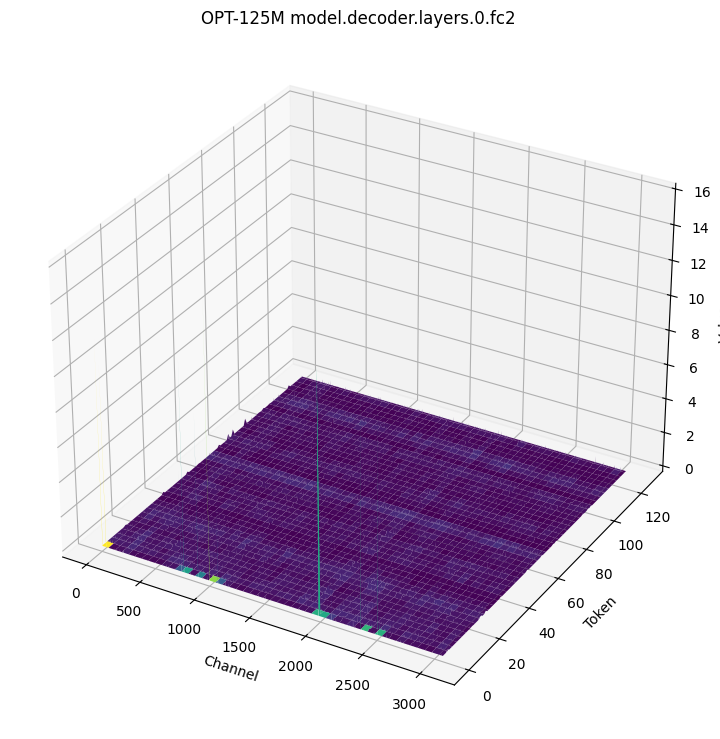

In [192]:
import matplotlib.pyplot as plt

sample_idx = 1

A = Z[sample_idx].abs().numpy()
seq_len, num_channels = A.shape

X, Y = np.meshgrid(
    np.arange(num_channels),
    np.arange(seq_len),
)

fig = plt.figure(figsize = (9, 11))
ax = fig.add_subplot(111, projection= "3d")

ax.plot_surface(
    X,
    Y,
    A,
    cmap = "viridis",
    linewidth = 0,
    antialiased = True
)

ax.set_xlabel("Channel")
ax.set_ylabel("Token")
ax.set_zlabel("Value")
ax.set_title(f"OPT-125M {target_module_name}")

plt.show()

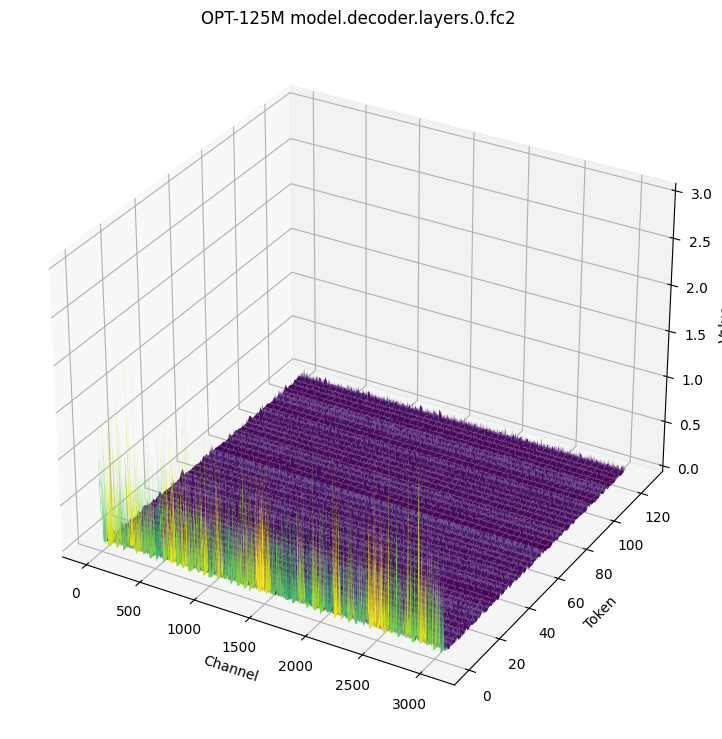

In [193]:
G = torch.randn(num_channels, num_channels)
R, _ = torch.linalg.qr(G)

XR = Z[sample_idx] @ R
XR = XR.abs().cpu().numpy()


X, Y = np.meshgrid(
    np.arange(num_channels),
    np.arange(seq_len),
)

fig = plt.figure(figsize = (9, 11))
ax = fig.add_subplot(111, projection= "3d")

ax.plot_surface(
    X,
    Y,
    XR,
    cmap = "viridis",
    linewidth = 0,
    antialiased = True
)

ax.set_xlabel("Channel")
ax.set_ylabel("Token")
ax.set_zlabel("Value")
ax.set_title(f"OPT-125M {target_module_name}")

plt.show()

fc2 weight shape: torch.Size([3072, 768])


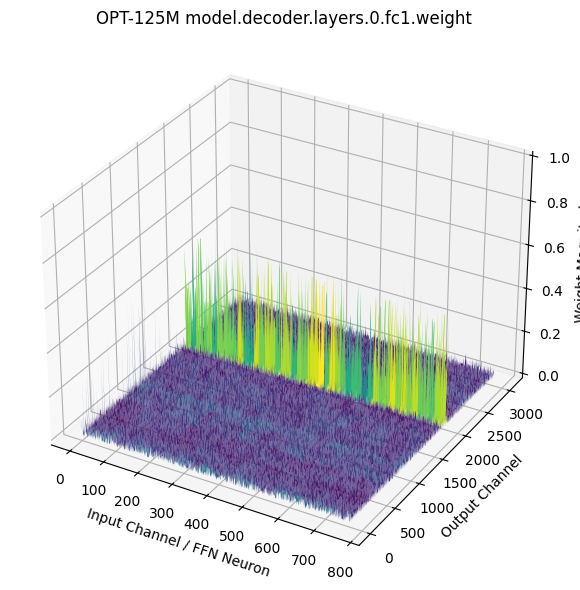

In [197]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# fc2 weight 꺼내기
W = model.model.decoder.layers[0].fc1.weight.detach().float().cpu()   # [768, 3072]

print("fc2 weight shape:", W.shape)

# 절댓값으로 볼지, signed 값으로 볼지 선택
Z = W.abs().numpy()     # magnitude 보기
# Z = W.numpy()         # signed weight 보기

out_channels, in_channels = Z.shape   # (768, 3072)

X, Y = np.meshgrid(
    np.arange(in_channels),    # input channel / FFN neuron
    np.arange(out_channels),   # output channel
)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
)

ax.set_xlabel("Input Channel / FFN Neuron")
ax.set_ylabel("Output Channel")
ax.set_zlabel("Weight Magnitude")
ax.set_title("OPT-125M model.decoder.layers.0.fc1.weight")

plt.tight_layout()
plt.show()